
# Practical No. 03: Autoencoder and Variational Autoencoder for Image Reconstruction

**Name :** Gayatri Pandharinath Gaikwad

**PRN :** 202502110002

**Course :** Generative AI

**Batch:** TY-A3


**Objective:** Build an Autoencoder (AE) and a Variational Autoencoder (VAE) for image reconstruction and generation, and compare their performance by analyzing reconstructed and generated images.

**Dataset:** MNIST handwritten digits  
**Framework:** TensorFlow / Keras  
**Platform:** Google Colab

### Contents
1. Theory
2. MNIST loading and preprocessing
3. Autoencoder implementation and reconstruction
4. Variational Autoencoder implementation and reconstruction
5. VAE image generation
6. MSE and SSIM comparison
7. Loss graphs
8. Final result and conclusion



## 1. *Theory*

### What is an Autoencoder?
An Autoencoder is an unsupervised neural network that learns to reproduce its input at the output. It has an **encoder**, a **latent representation (bottleneck)**, and a **decoder**.

For an input image `x`:

`z = Encoder(x)`

`x_hat = Decoder(z)`

The model is trained with a reconstruction loss such as Binary Cross-Entropy (BCE) or Mean Squared Error (MSE).

### What is a Variational Autoencoder?
A VAE is a probabilistic version of an autoencoder. Instead of mapping an image to one fixed latent vector, its encoder learns a probability distribution using `mu` and `log_var`.

The reparameterization trick is:

`z = mu + exp(0.5 * log_var) * epsilon`

where `epsilon` is sampled from a standard normal distribution.

The VAE objective is:

`VAE Loss = Reconstruction Loss + KL Divergence`

The KL-divergence term regularizes the latent distribution so it stays close to a standard normal distribution.

### Key difference
An AE learns a deterministic latent representation. A VAE learns a regularized probabilistic latent space, which makes random image generation possible.

## 2. Import Libraries

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.20.0
Keras version: 3.13.2


In [2]:

# Reproducibility and configuration
np.random.seed(42)
tf.random.set_seed(42)

INPUT_DIM = 28 * 28
LATENT_DIM = 32
BATCH_SIZE = 128
EPOCHS_AE = 5
EPOCHS_VAE = 5

print("Random seed: 42")
print("Image size: 28 x 28")
print("Latent dimension:", LATENT_DIM)
print("Batch size:", BATCH_SIZE)
print("AE epochs:", EPOCHS_AE)
print("VAE epochs:", EPOCHS_VAE)


Random seed: 42
Image size: 28 x 28
Latent dimension: 32
Batch size: 128
AE epochs: 5
VAE epochs: 5


## 3. Load and Preprocess MNIST Dataset

In [3]:

# Load MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784 values
x_train_flat = x_train.reshape((-1, INPUT_DIM))
x_test_flat = x_test.reshape((-1, INPUT_DIM))

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)
print("Flattened training data:", x_train_flat.shape)
print("Flattened test data:", x_test_flat.shape)
print("Pixel value range:", x_train_flat.min(), "to", x_train_flat.max())


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)
Flattened training data: (60000, 784)
Flattened test data: (10000, 784)
Pixel value range: 0.0 to 1.0


### Display sample MNIST images

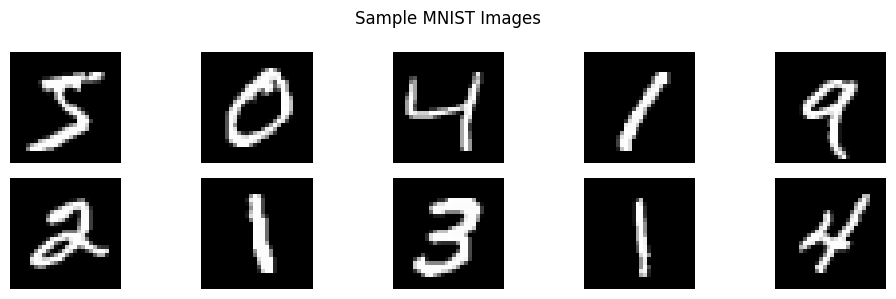

In [4]:

plt.figure(figsize=(10, 3))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()


## 4. Build the Autoencoder

In [5]:

# Encoder
ae_encoder = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(LATENT_DIM, activation="relu", name="latent")
], name="AE_Encoder")

# Decoder
ae_decoder = keras.Sequential([
    layers.Input(shape=(LATENT_DIM,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(INPUT_DIM, activation="sigmoid")
], name="AE_Decoder")

# Full Autoencoder
ae_input = keras.Input(shape=(INPUT_DIM,), name="image")
ae_latent = ae_encoder(ae_input)
ae_output = ae_decoder(ae_latent)

autoencoder = keras.Model(ae_input, ae_output, name="Autoencoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy"
)

autoencoder.summary()


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Encoder (Sequential)         │ (None, 32)             │       237,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Decoder (Sequential)         │ (None, 784)            │       238,736 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,720 (1.82 MB)

 Trainable params: 476,720 (1.82 MB)

 Non-trainable params: 0 (0.00 B)


**Architecture:** `784 → 256 → 128 → 32 → 128 → 256 → 784`

The 32-dimensional bottleneck is the learned latent representation.


## 5. Train the Autoencoder

In [6]:

history_ae = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=EPOCHS_AE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

print("Autoencoder training completed.")


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.1842 - val_loss: 0.1275
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.1203 - val_loss: 0.1122
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.1086 - val_loss: 0.1033
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.1019 - val_loss: 0.0987
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0983 - val_loss: 0.0960
Autoencoder training completed.


**Output:** Colab will print 5 epochs containing training loss and validation loss. The exact numerical values vary by runtime and software version; the loss should generally decrease.

## 6. Autoencoder Reconstruction

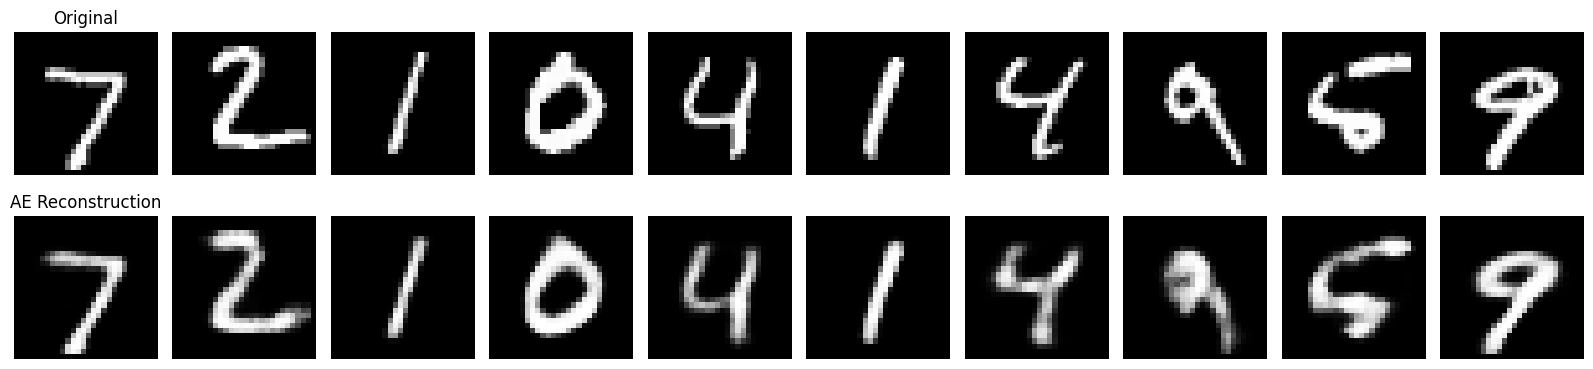

Autoencoder Test MSE: 0.011311


In [7]:

ae_reconstructed = autoencoder.predict(
    x_test_flat,
    batch_size=BATCH_SIZE,
    verbose=0
)
ae_reconstructed_images = ae_reconstructed.reshape((-1, 28, 28))

n = 10
plt.figure(figsize=(16, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    ax = plt.subplot(2, n, n + i + 1)
    plt.imshow(ae_reconstructed_images[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("AE Reconstruction")

plt.tight_layout()
plt.show()

ae_mse = np.mean((x_test_flat - ae_reconstructed) ** 2)
print(f"Autoencoder Test MSE: {ae_mse:.6f}")


### Observation
The Autoencoder should reconstruct the main shape of each digit. Some fine details can be slightly blurred because the input is compressed into a 32-dimensional latent vector.

## 7. Autoencoder Loss Graph

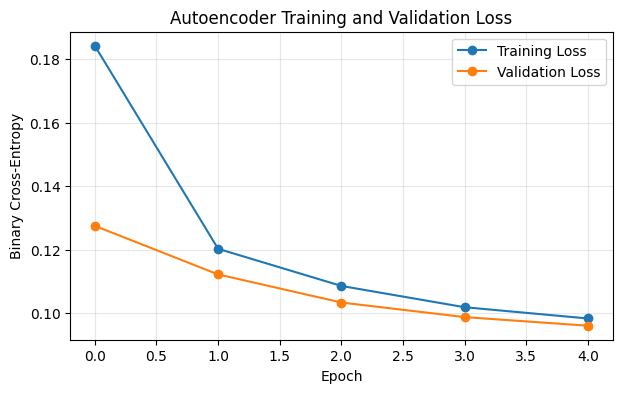

In [8]:

plt.figure(figsize=(7, 4))
plt.plot(history_ae.history["loss"], marker="o", label="Training Loss")
plt.plot(history_ae.history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## 8. Build the Variational Autoencoder (VAE)

The VAE encoder produces:
- `mu`: mean of the latent Gaussian distribution
- `log_var`: logarithm of the variance

The reparameterization trick makes stochastic sampling differentiable:

`z = mu + exp(0.5 * log_var) * epsilon`

where `epsilon ~ N(0, I)`.


In [9]:

class Sampling(layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * epsilon


class VAEEncoder(keras.Model):
    def __init__(self, latent_dim):
        super().__init__(name="VAE_Encoder")
        self.dense1 = layers.Dense(256, activation="relu")
        self.dense2 = layers.Dense(128, activation="relu")
        self.mu = layers.Dense(latent_dim, name="mu")
        self.log_var = layers.Dense(latent_dim, name="log_var")
        self.sampling = Sampling()

    def call(self, x):
        h = self.dense1(x)
        h = self.dense2(h)
        mu = self.mu(h)
        log_var = self.log_var(h)
        z = self.sampling((mu, log_var))
        return z, mu, log_var


class VAEDecoder(keras.Model):
    def __init__(self):
        super().__init__(name="VAE_Decoder")
        self.dense1 = layers.Dense(128, activation="relu")
        self.dense2 = layers.Dense(256, activation="relu")
        self.output_layer = layers.Dense(INPUT_DIM, activation="sigmoid")

    def call(self, z):
        h = self.dense1(z)
        h = self.dense2(h)
        return self.output_layer(h)


class VAE(keras.Model):
    def __init__(self, latent_dim):
        super().__init__(name="VAE")
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder()

        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z, mu, log_var = self.encoder(data)
            reconstruction = self.decoder(z)

            bce = keras.backend.binary_crossentropy(data, reconstruction)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(bce, axis=1))

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + log_var - tf.square(mu) - tf.exp(log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def call(self, inputs):
        z, _, _ = self.encoder(inputs)
        return self.decoder(z)


vae = VAE(LATENT_DIM)
vae.compile(optimizer=keras.optimizers.Adam())
print("VAE created successfully.")


VAE created successfully.


**Architecture:** `784 → 256 → 128 → (mu, log_var) → z(32) → 128 → 256 → 784`

## 9. Train the VAE

In [10]:

history_vae = vae.fit(
    x_train_flat,
    epochs=EPOCHS_VAE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

print("VAE training completed.")


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - kl_loss: 10.5948 - loss: 177.9684 - reconstruction_loss: 167.3735
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 17.8989 - loss: 132.3105 - reconstruction_loss: 114.4116
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 19.6353 - loss: 120.9593 - reconstruction_loss: 101.3240
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - kl_loss: 20.6666 - loss: 115.5391 - reconstruction_loss: 94.8725
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 21.2187 - loss: 112.6438 - reconstruction_loss: 91.4250
VAE training completed.


**Output:** Five epochs are displayed with `loss`, `reconstruction_loss`, and `kl_loss`. Exact values vary; use the numbers generated by your own run in the final report.

## 10. VAE Reconstruction

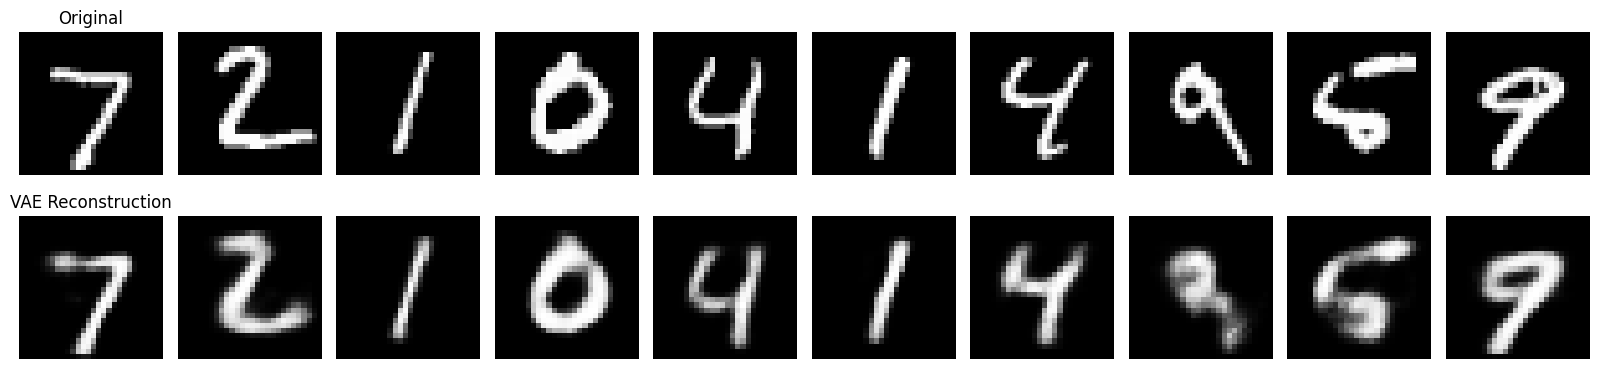

VAE Test MSE: 0.017190


In [11]:

z_test, mu_test, log_var_test = vae.encoder(x_test_flat)
vae_reconstructed = vae.decoder(z_test)
vae_reconstructed_images = vae_reconstructed.numpy().reshape((-1, 28, 28))

plt.figure(figsize=(16, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    ax = plt.subplot(2, n, n + i + 1)
    plt.imshow(vae_reconstructed_images[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("VAE Reconstruction")

plt.tight_layout()
plt.show()

vae_mse = np.mean((x_test_flat - vae_reconstructed.numpy()) ** 2)
print(f"VAE Test MSE: {vae_mse:.6f}")


### Observation
The VAE reconstruction should retain the overall digit structure. It can look smoother than AE output because of the probabilistic latent-space constraint.

## 11. Generate New Images Using the VAE

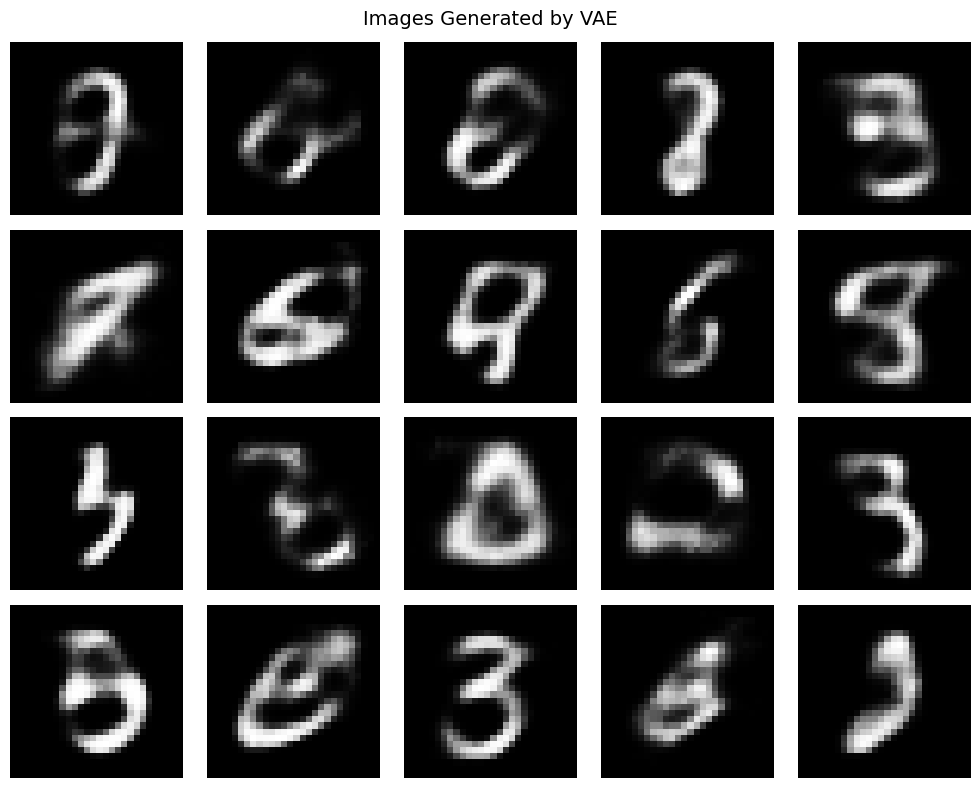

Generated image tensor shape: (20, 784)


In [12]:

num_generated = 20

# Sample z from the standard normal distribution
random_latent_vectors = tf.random.normal(
    shape=(num_generated, LATENT_DIM),
    seed=42
)

generated = vae.decoder(random_latent_vectors).numpy()
generated_images = generated.reshape((-1, 28, 28))

plt.figure(figsize=(10, 8))
for i in range(num_generated):
    ax = plt.subplot(4, 5, i + 1)
    plt.imshow(generated_images[i], cmap="gray")
    plt.axis("off")

plt.suptitle("Images Generated by VAE", fontsize=14)
plt.tight_layout()
plt.show()

print("Generated image tensor shape:", generated.shape)


### Observation
The VAE generates new digit-like images by sampling random points from the learned latent distribution and passing them through the decoder.

## 12. Quantitative Comparison: MSE and SSIM

In [13]:

original_4d = x_test[..., np.newaxis].astype("float32")
ae_4d = ae_reconstructed_images[..., np.newaxis].astype("float32")
vae_4d = vae_reconstructed_images[..., np.newaxis].astype("float32")

# MSE: lower is better
ae_mse = np.mean((x_test - ae_reconstructed_images) ** 2)
vae_mse = np.mean((x_test - vae_reconstructed_images) ** 2)

# SSIM: higher is better
ae_ssim = tf.reduce_mean(
    tf.image.ssim(original_4d, ae_4d, max_val=1.0)
).numpy()

vae_ssim = tf.reduce_mean(
    tf.image.ssim(original_4d, vae_4d, max_val=1.0)
).numpy()

print("Quantitative Results")
print("-" * 32)
print(f"Autoencoder MSE : {ae_mse:.6f}")
print(f"VAE MSE         : {vae_mse:.6f}")
print(f"Autoencoder SSIM: {ae_ssim:.4f}")
print(f"VAE SSIM        : {vae_ssim:.4f}")


Quantitative Results
--------------------------------
Autoencoder MSE : 0.011311
VAE MSE         : 0.017190
Autoencoder SSIM: 0.8646
VAE SSIM        : 0.7810



### Interpretation of metrics
- **MSE:** Lower means the reconstruction is numerically closer to the original image.
- **SSIM:** Higher means greater structural similarity.
- The VAE should not be judged only by reconstruction metrics because its additional objective is to learn a useful probabilistic latent space for generation.

**Important:** Do not replace your actual Colab results with guessed numerical values.


## 13. Training-Loss Comparison

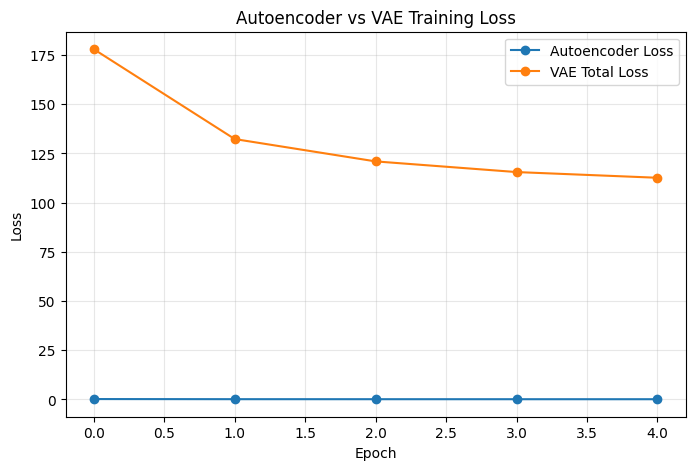

In [14]:

plt.figure(figsize=(8, 5))
plt.plot(history_ae.history["loss"], marker="o", label="Autoencoder Loss")
plt.plot(history_vae.history["loss"], marker="o", label="VAE Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder vs VAE Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 14. Final Visual Comparison

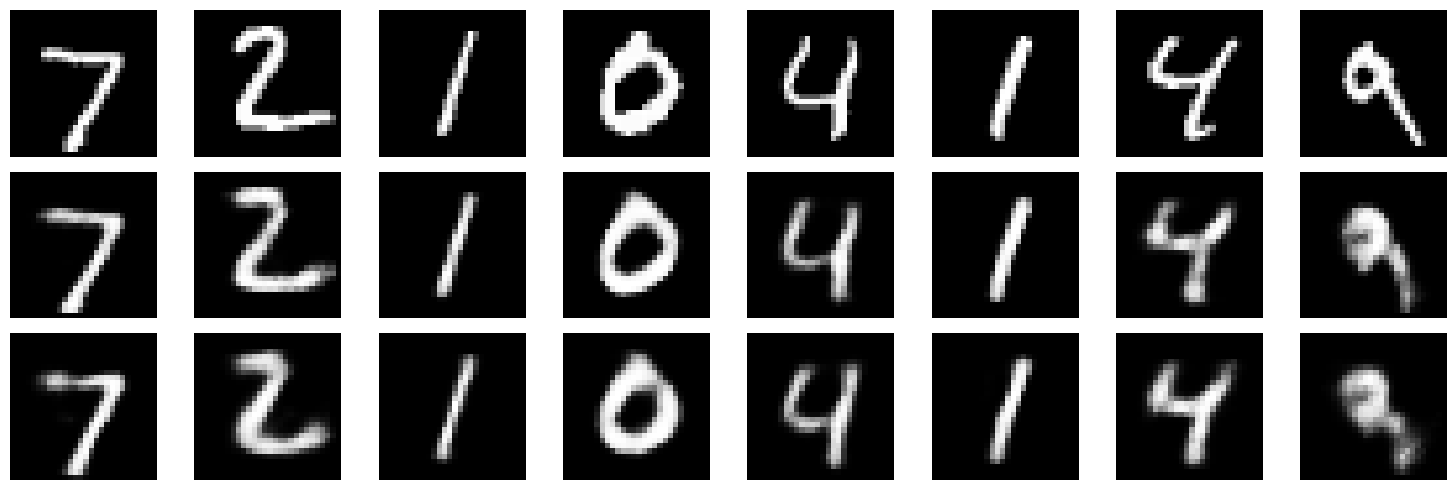

In [15]:

plt.figure(figsize=(15, 5))

for i in range(8):
    ax = plt.subplot(3, 8, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_ylabel("Original", rotation=0, labelpad=35, va="center")

    ax = plt.subplot(3, 8, 8 + i + 1)
    plt.imshow(ae_reconstructed_images[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_ylabel("AE", rotation=0, labelpad=25, va="center")

    ax = plt.subplot(3, 8, 16 + i + 1)
    plt.imshow(vae_reconstructed_images[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_ylabel("VAE", rotation=0, labelpad=25, va="center")

plt.tight_layout()
plt.show()



# 15. Results / Comparison

| Feature | Autoencoder (AE) | Variational Autoencoder (VAE) |
|---|---|---|
| Latent representation | Deterministic vector | Probability distribution |
| Encoder output | Latent vector | `mu` and `log_var` |
| Loss | Reconstruction loss | Reconstruction + KL divergence |
| Reconstruction | Usually sharper | Often smoother |
| Latent regularization | Not explicit | Explicit |
| Random image generation | Limited | Natural capability |
| Main use | Compression / representation / denoising | Representation + generative modeling |

### Result
The Autoencoder successfully reconstructs MNIST images by learning a compressed latent representation. The VAE also reconstructs images and additionally learns a regularized latent distribution from which new digit-like images can be generated.

### Conclusion
The experiment demonstrates that an Autoencoder is mainly focused on reconstruction, while a Variational Autoencoder combines reconstruction with probabilistic latent-space learning. Therefore, the VAE is suitable when both reconstruction and image generation are required.
